In [1]:
#import libararies
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

import os

/Users/sita/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#Develope CNN model and compile it
classifier = Sequential()
classifier.add(Conv2D(64,(3,3), input_shape=(64, 64, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))
classifier.add(Conv2D(64,(3,3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2,2)))

/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
#add the final dense layers, dropout layer and output layer
classifier.add(Flatten())
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))

In [ ]:
#compile the model
classifier.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy']
                   )

In [5]:
#transform the importe data 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#download the dataset
#getting access denied error from google storage
'''
_URL='https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip=tf.keras.utils.get_file(
    'cats_and_dogs.zip',
    origin=_URL,
    extract=True
    )

PATH = os.path.join(
    os.path.dirname(path_to_zip),
    'cats_and_dogs_filtered'
    )
'''


#used the following command in terminal to download the dataset manually
#curl -LOk https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
#PATH = '/Users/sita/Downloads/cats_and_dogs_filtered'

#import zipfile
#with zipfile.ZipFile("cats_and_dogs_filtered.zip", "r") as zip_ref: zip_ref.extractall("cats_and_dogs_filtered")

Exception: URL fetch failure on https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip: 403 -- Forbidden

In [17]:
#set up directories
PATH = os.path.join(os.getcwd(), 'cats_and_dogs_filtered')
print(PATH)
training_dir = os.path.join(PATH, 'train')
testing_dir = os.path.join(PATH, 'validation')

#directory with the training cat pictures
cats_training_dir = os.path.join(training_dir, 'cats')
print(cats_training_dir)

#directory with the training dog pictures
dogs_training_dir = os.path.join(training_dir, 'dogs')  
print(dogs_training_dir)

#directory with the testing cat pictures
cats_testing_dir = os.path.join(testing_dir, 'cats')
print(cats_testing_dir)

#directory with the testing dog pictures
dogs_testing_dir = os.path.join(testing_dir, 'dogs')
print(dogs_testing_dir)


/Users/sita/Documents/MyApps/mypython/cats_and_dogs_filtered
/Users/sita/Documents/MyApps/mypython/cats_and_dogs_filtered/train/cats
/Users/sita/Documents/MyApps/mypython/cats_and_dogs_filtered/train/dogs
/Users/sita/Documents/MyApps/mypython/cats_and_dogs_filtered/validation/cats
/Users/sita/Documents/MyApps/mypython/cats_and_dogs_filtered/validation/dogs


In [18]:
#find the number of elements in each directory
cats_training_num =len(os.listdir(cats_training_dir))
dogs_training_num =len(os.listdir(dogs_training_dir))

cats_testing_num =len(os.listdir(cats_testing_dir))
dogs_testing_num =len(os.listdir(dogs_testing_dir))

total_training_num = cats_training_num + dogs_training_num
total_testing_num = cats_testing_num + dogs_testing_num

print('total training cat images:', cats_training_num)
print('total training dog images:', dogs_training_num)

print('total testing cat images:', cats_testing_num)
print('total testing dog images:', dogs_testing_num)

print("--")

print("Total training images:", total_training_num)
print("Total testing images:", total_testing_num)   

total training cat images: 1000
total training dog images: 1000
total testing cat images: 500
total testing dog images: 500
--
Total training images: 2000
Total testing images: 1000


In [20]:
#load the training data and testing data, and display the label map

train_data  = train_datagen.flow_from_directory(
    batch_size=128,
    directory=training_dir,
    target_size=(64, 64),
    class_mode='binary'
    )

test_data = test_datagen.flow_from_directory(
    batch_size=128,
    directory=testing_dir,
    target_size=(64, 64),
    class_mode='binary'
    )

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [21]:
#display numerical identities of classes
label_map = (train_data.class_indices)
print(label_map)

{'cats': 0, 'dogs': 1}


In [22]:
#train the model
classifier.fit(
    train_data,
    epochs=30,
    validation_data=test_data
)

/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.5054 - loss: 0.7719 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.5060 - loss: 0.6922 - val_accuracy: 0.5010 - val_loss: 0.6886
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.5586 - loss: 0.6859 - val_accuracy: 0.6150 - val_loss: 0.6713
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.5953 - loss: 0.6696 - val_accuracy: 0.6250 - val_loss: 0.6435
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.6176 - loss: 0.6566 - val_accuracy: 0.6140 - val_loss: 0.6573
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.6588 - loss: 0.6301 - val_accuracy: 0.6140 - val_loss: 0.6274
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.6818 - loss: 0.5897 - val_accuracy: 0.6670 - val_loss: 0.6040
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.6904 - loss: 0.5917 - val_accuracy: 0.

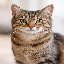

In [25]:
#carry out inference
import numpy as np
from tensorflow.keras.preprocessing import image

test_image_1 = image.load_img('Dog.png', target_size=(64,64))
test_image_2 = image.load_img('Cat.png', target_size=(64,64))

test_image_1

test_image_2

In [26]:
test_image_1 = image.img_to_array(test_image_1)
test_image_2 = image.img_to_array(test_image_2) 

test_image_1 = test_image_1.reshape((1, 64, 64, 3))
test_image_2 = test_image_2.reshape((1, 64, 64, 3))

result1 = classifier.predict(test_image_1)
result2 = classifier.predict(test_image_2)

print(result1, result2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[1.]] [[0.]]


In [29]:
if result1 == 1:
    prediction1 = "dog"
else:
    prediction1 = "cat"

print(prediction1)

if result2 == 1:
    prediction2 = "dog"
else:
    prediction2 = "cat"

print(prediction2)   


dog
cat
